In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob



In [3]:
import json

# Get list of all JSON files in the directory
json_files = glob.glob('water_level/*.json-*')

dfs = []
bad_files = 0

for file in json_files:
    try:
        # Try fast pandas read first
        df_temp = pd.read_json(file, lines=True)
        dfs.append(df_temp)
    except Exception as e:
        # Fallback: read line-by-line for problematic files
        print(f"Recovering from error in {file}: {type(e).__name__}")
        data = []
        try:
            with open(file, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:  # Skip empty lines
                        continue
                    try:
                        data.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass  # Skip malformed JSON lines
            if data:
                dfs.append(pd.DataFrame(data))
                print(f"  Recovered {len(data)} records from {file}")
            else:
                bad_files += 1
        except Exception as e2:
            print(f"  Could not recover {file}: {e2}")
            bad_files += 1

if bad_files > 0:
    print(f"\nWarning: {bad_files} file(s) could not be read")

# Concatenate all dataframes
df = pd.concat(dfs, ignore_index=True)

# Remove duplicated rows
df = df.drop_duplicates()
# Remove missing values
df = df.dropna(subset=['time', 'level'])

# Parse datetime
df['datetime'] = pd.to_datetime(df['time'], format='mixed')
# Discard data before 2024-10-23 00:00:00
df = df[df['datetime'] >= '2024-10-23 00:00:00'] 
df.set_index('datetime', inplace=True)

print(f"\nLoaded {len(df)} total records spanning {df.index.min()} to {df.index.max()}")

Recovering from error in water_level/water_level.json-2025-12-28T06-19-12.428Z: ValueError
  Recovered 892 records from water_level/water_level.json-2025-12-28T06-19-12.428Z
Recovering from error in water_level/water_level.json-2026-01-05T12-41-17.818Z: ValueError
  Recovered 2967 records from water_level/water_level.json-2026-01-05T12-41-17.818Z
Recovering from error in water_level/water_level.json-2026-07-09T12-19-04.884Z: ValueError
  Recovered 1266 records from water_level/water_level.json-2026-07-09T12-19-04.884Z
Recovering from error in water_level/water_level.json-2026-07-17T11-19-22.047Z: ValueError
  Recovered 148 records from water_level/water_level.json-2026-07-17T11-19-22.047Z
Recovering from error in water_level/water_level.json-2026-07-17T12-29-55.445Z: ValueError
  Recovered 98 records from water_level/water_level.json-2026-07-17T12-29-55.445Z
Recovering from error in water_level/water_level.json-2026-07-18T11-45-37.400Z: ValueError
  Recovered 621 records from water_lev

In [4]:
df.drop(columns=['time'], inplace=True)
df

,level
datetime,
2024-10-23 00:00:00,2.549554
2024-10-23 00:00:01,2.590929
2024-10-23 00:00:02,2.632304
2024-10-23 00:00:03,2.590929
2024-10-23 00:00:04,2.508162
...,...
2026-07-20 12:48:05,23.282559
2026-07-20 12:48:08,23.282559
2026-07-20 12:48:09,23.323934


<Axes: title={'center': 'Water Level (cm) - 2025-09-23'}, xlabel='datetime'>

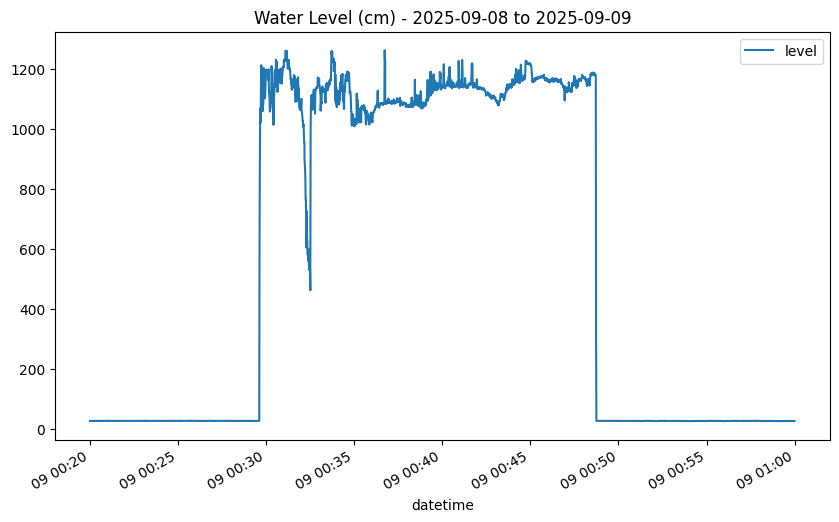

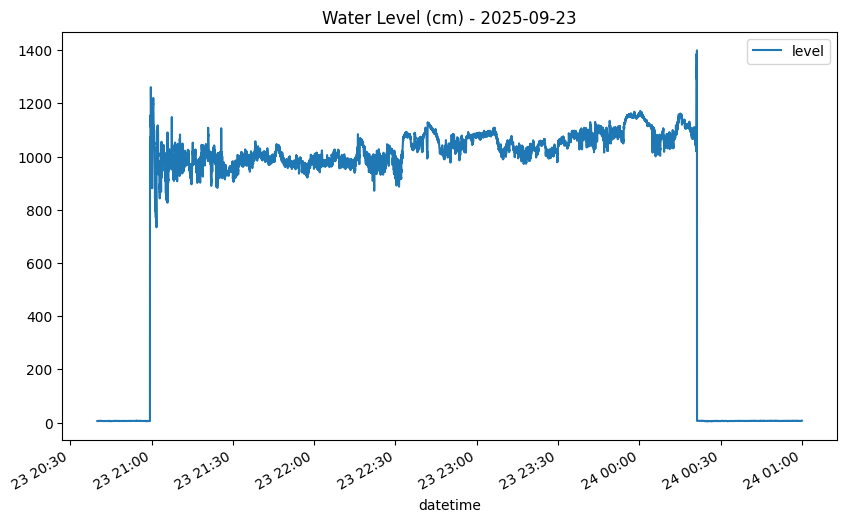

In [5]:
df.sort_index(inplace=True)
df.loc['2025-09-09 00:20:00':'2025-09-09 01:00:00'].plot(y='level',  figsize=(10,6), title='Water Level (cm) - 2025-09-08 to 2025-09-09')
df.loc['2025-09-23 20:40:00':'2025-09-24 01:00:00'].plot(y='level',  figsize=(10,6), title='Water Level (cm) - 2025-09-23')

<Axes: title={'center': 'Water Level (cm) - 2025-09-23'}, xlabel='datetime'>

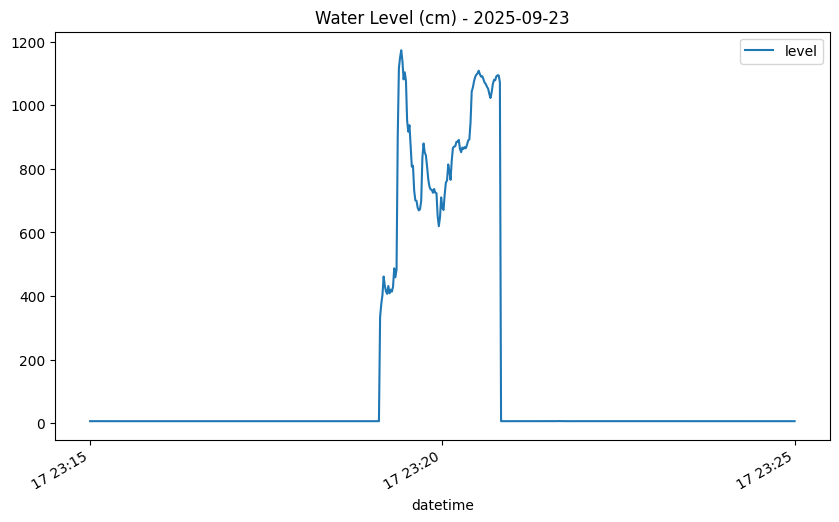

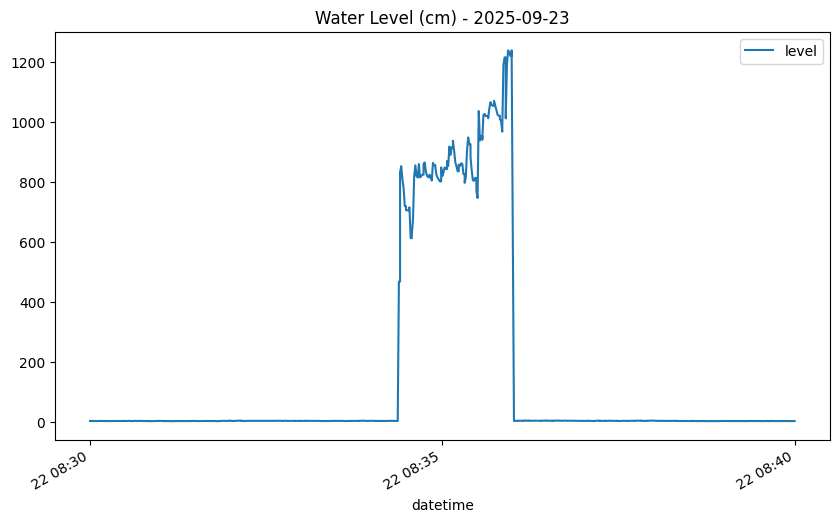

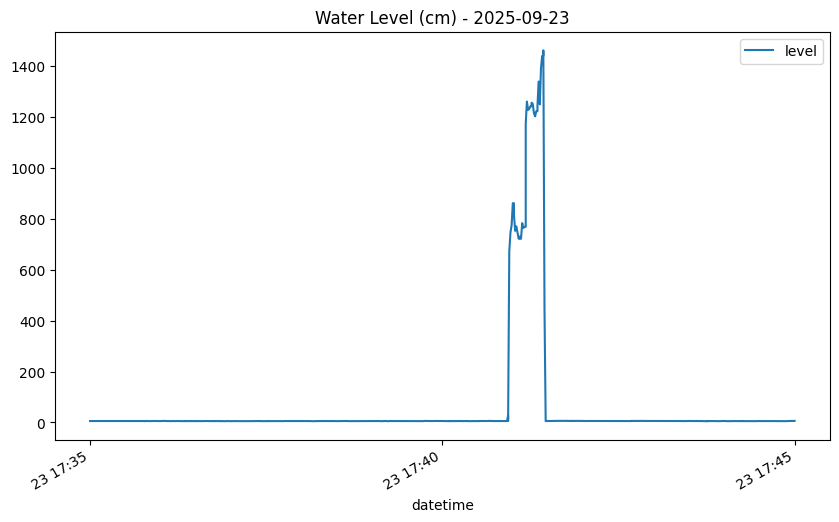

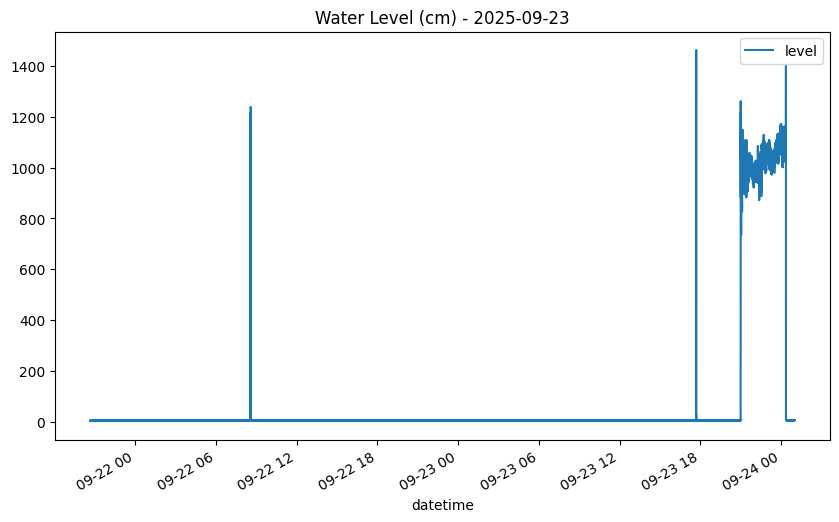

In [6]:
df.loc['2025-09-17 23:15:00':'2025-09-17 23:25:00'].plot(y='level',  figsize=(10,6), title='Water Level (cm) - 2025-09-23')
df.loc['2025-09-22 08:30:00':'2025-09-22 08:40:00'].plot(y='level',  figsize=(10,6), title='Water Level (cm) - 2025-09-23')
df.loc['2025-09-23 17:35:00':'2025-09-23 17:45:00'].plot(y='level',  figsize=(10,6), title='Water Level (cm) - 2025-09-23')

df.loc['2025-09-21 20:40:00':'2025-09-24 01:00:00'].plot(y='level',  figsize=(10,6), title='Water Level (cm) - 2025-09-23')

In [7]:
df_hourly = df.resample('h').mean()
df_hourly['depth'] = df_hourly['level'].apply(lambda x: -1.2 + x/100)
df_hourly


,level,depth
datetime,,
2024-10-23 00:00:00,2.577479,-1.174225
2024-10-23 01:00:00,2.579437,-1.174206
2024-10-23 02:00:00,2.584412,-1.174156
2024-10-23 03:00:00,2.583234,-1.174168
2024-10-23 04:00:00,2.576246,-1.174238
...,...,...
2026-07-20 08:00:00,18.523713,-1.014763
2026-07-20 09:00:00,23.313079,-0.966869
2026-07-20 10:00:00,23.273639,-0.967264


<Axes: title={'center': 'Water Depth (m) - Hourly Average'}, xlabel='datetime'>

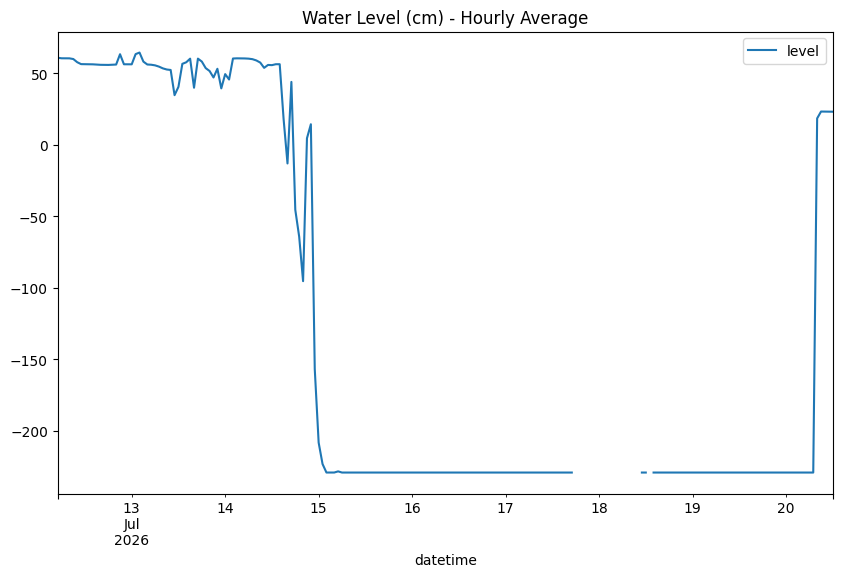

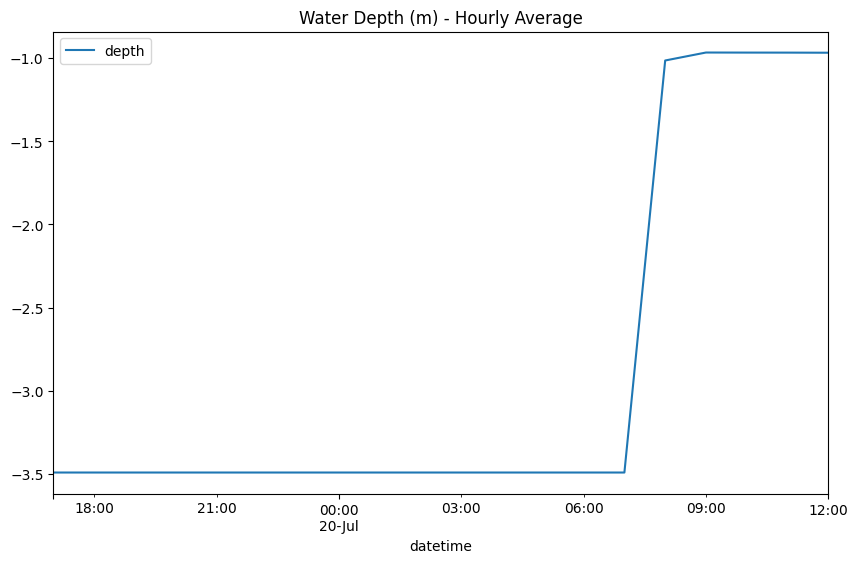

In [8]:
df_hourly.tail(200).plot(y='level', figsize=(10,6), title='Water Level (cm) - Hourly Average')
df_hourly.tail(20).plot(y='depth', figsize=(10,6), title='Water Depth (m) - Hourly Average')

In [9]:
# dfx['datetime'] = pd.to_datetime(dfx['time'], format='%m/%d/%Y %I:%M:%S %p')
# dfx

Text(0.5, 0, 'Time')

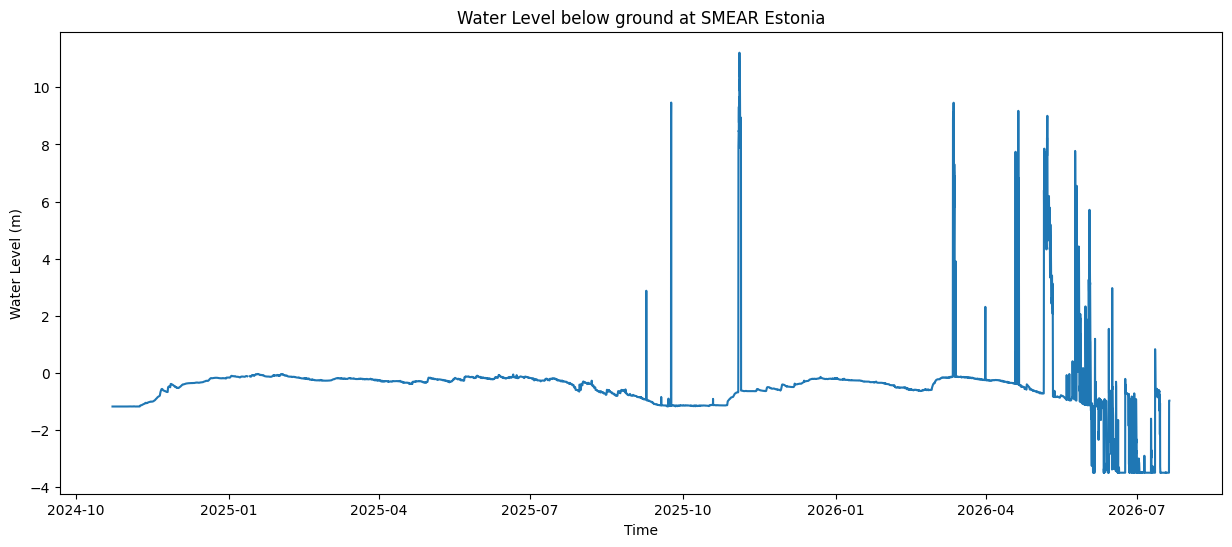

In [10]:
# Plot the data
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_hourly.index, df_hourly['depth'], label='Water Level')
ax.set_title('Water Level below ground at SMEAR Estonia')
ax.set_ylabel('Water Level (m)')
ax.set_xlabel('Time')


Text(0.5, 0, 'Time')

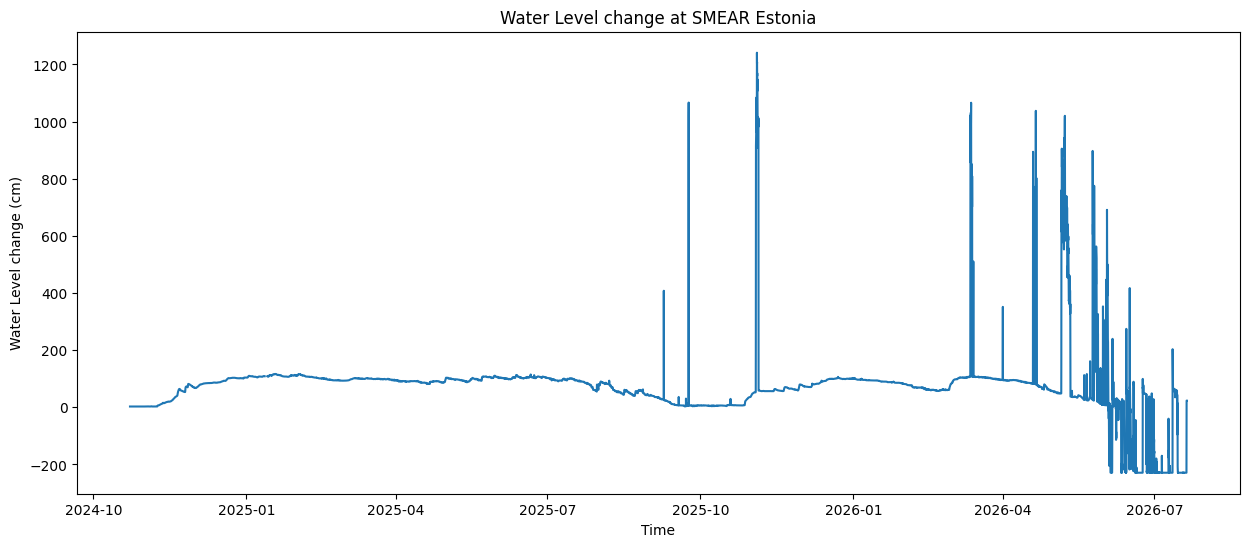

In [11]:
# Plot the data
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_hourly.index, df_hourly['level'], label='Water Level')
ax.set_title('Water Level change at SMEAR Estonia')
ax.set_ylabel('Water Level change (cm)')
ax.set_xlabel('Time')

In [12]:
# Read in weather data from csv

cols = ['wind_direction', 'wind_speed', 'temperature', 'humidity', 'pressure',
        'rain', 'rd', 'ri', 'hail', 'hd', 'hi']

dfm = pd.read_csv('meteo/weather.csv', header=None, parse_dates=True, index_col=0)
dfm.columns = cols
dfm.index.name = 'date'
# Discard data before 2024-10-23 00:00:00
dfm = dfm.loc['2024-10-23 00:00:00':]
dfm.tail()

,wind_direction,wind_speed,temperature,humidity,pressure,rain,rd,ri,hail,hd,hi
date,,,,,,,,,,,
2026-07-12 06:40:00,328.0,0.5,19.8,90.9,1010.5,0.0,0.0,0.0,0.0,0.0,0.0
2026-07-12 06:50:00,315.0,0.4,19.9,92.3,1010.3,0.0,0.0,0.0,0.0,0.0,0.0
2026-07-12 07:00:00,317.0,0.3,19.6,91.6,1010.5,0.3,350.0,0.3,0.0,0.0,0.0
2026-07-12 07:10:00,245.0,0.2,19.3,93.8,1010.7,0.0,10.0,0.0,0.0,0.0,0.0
2026-07-12 07:20:00,208.0,0.2,19.2,96.1,1010.5,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Subset the data to only include the rain column

dfrain = dfm[['rain']]

# Resample to hourly data
dfrainJS = dfrain.resample('h').sum()
dfrainJS.tail()

,rain
date,
2026-07-12 03:00:00,0.0
2026-07-12 04:00:00,0.0
2026-07-12 05:00:00,0.0
2026-07-12 06:00:00,0.0
2026-07-12 07:00:00,0.3


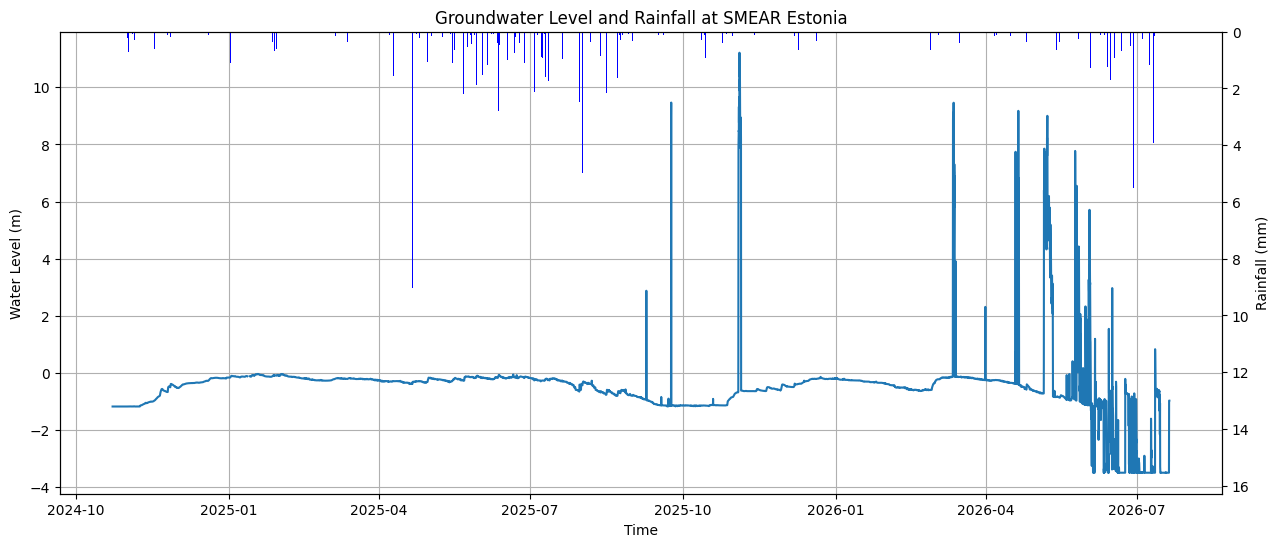

In [14]:
# Plot the water level and rain data together
fig, ax = plt.subplots(figsize=(15, 6)) 
ax.plot(df_hourly.index, df_hourly['depth'], label='Water Level')
ax.set_title('Groundwater Level and Rainfall at SMEAR Estonia')
ax.set_ylabel('Water Level (m)')
ax.set_xlabel('Time')
ax.grid()
ax2 = ax.twinx()
ax2.bar(dfrainJS.index, dfrainJS['rain'], width=0.1, color='blue', label='Rainfall')
ax2.invert_yaxis()
ax2.set_ylabel('Rainfall (mm)')
ax2.grid(False)
plt.show()


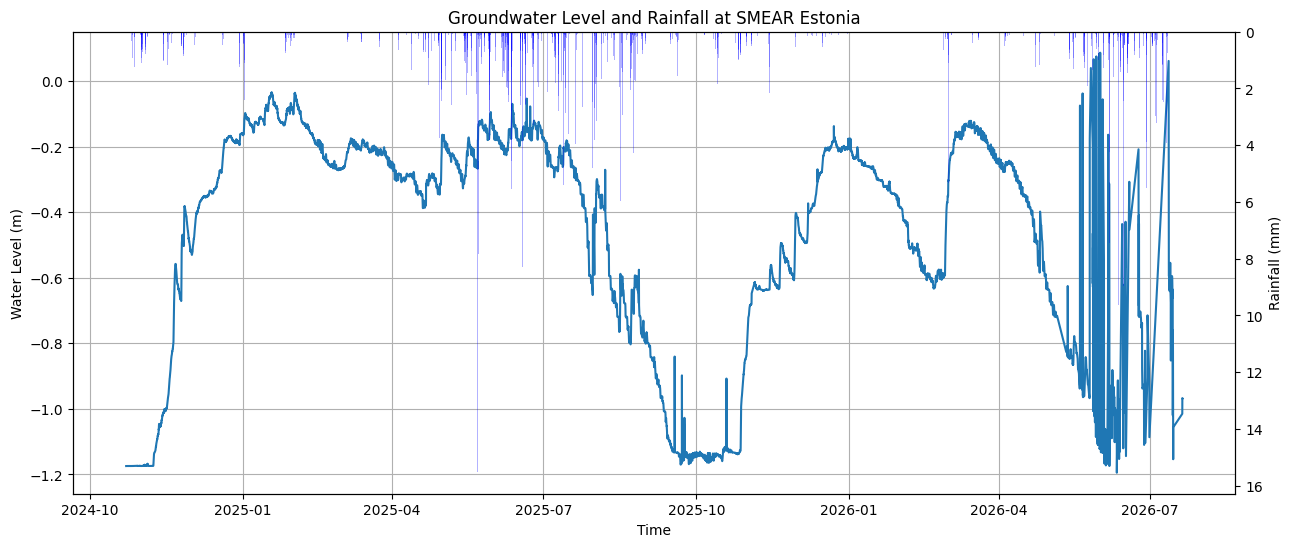

In [37]:
# Remove very high and very lowlevel values
df_hourly1 = df_hourly[df_hourly['level'] < 130]
df_hourly2 = df_hourly1[df_hourly1['level'] > 0]

# Plot the water level and rain data together
fig, ax = plt.subplots(figsize=(15, 6)) 
ax.plot(df_hourly2.index, df_hourly2['depth'], label='Water Level')
ax.set_title('Groundwater Level and Rainfall at SMEAR Estonia')
ax.set_ylabel('Water Level (m)')
ax.set_xlabel('Time')
ax.grid()
ax2 = ax.twinx()
ax2.bar(dfrainJS.index, dfrainJS['rain'], width=0.5, color='blue', alpha=0.3, label='Rainfall')
ax2.invert_yaxis()
ax2.set_ylabel('Rainfall (mm)')
ax2.grid(False)
plt.show()
